# nb09 -- Skip-connection model: bootstrap stability + null validation
Repeats nb07's validation (bootstrap resampling + permutation null baseline), now on the skip-connection architecture from nb08, since that model's direct-path importance is a structurally cleaner interpretability artifact than the hidden-only model's path-weight product.

Validated **separately** for the two paths, since they're on different scales and answer different questions:
- **Direct path** (`|W_direct|`) -- the primary deliverable. Is a protein's top direct predictor a stable, above-chance finding, or an artifact of one training run?
- **Hidden path** (`|W2 @ W1|`) -- secondary. Same check for the mediated signal.

Same data pipeline as nb06/nb07/nb08. All evaluation reported on train and test.

## Environment setup

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata scikit-misc
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/covid_citeseq_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Colab | BASE_PATH = /content/drive/MyDrive/covid_citeseq_project


## GPU check

In [2]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device (training only):', DEVICE)

Device (training only): cuda


## Imports and config

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

CHECKPOINT_PATH    = BASE_PATH / 'data' / 'processed' / 'covid_subsampled.h5ad'
GENE_MAPPING_PATH  = BASE_PATH / 'results' / 'tables' / 'nb02_covid_adt_gene_mapping.csv'
RESULTS_DIR        = BASE_PATH / 'results' / 'sparse_mlp_v3_validation'
MODELS_DIR         = RESULTS_DIR / 'checkpoints'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

N_HVGS       = 2000
DROP_GENES   = ['PDPN', 'KDR']  # zero-variance in GEX (see nb02 Step 3b)

HIDDEN_DIM        = 64
L1_LAMBDA_DIRECT  = 1e-4
L1_LAMBDA_FC1     = 1e-4
L1_LAMBDA_FC2     = 1e-4
BATCH_SIZE        = 256
NUM_EPOCHS        = 100
PATIENCE          = 15

TEST_SIZE     = 0.15
VAL_SIZE      = 0.15
RANDOM_STATE  = 42

# Validation run budgets -- each bootstrap/null run is a full training pass.
N_BOOTSTRAPS      = 5
N_NULL_PERMS      = 5
AUX_NUM_EPOCHS    = 40
AUX_PATIENCE      = 8
TOP_K_GENES       = 20

## Load checkpoint and gene mapping

In [4]:
covid = sc.read_h5ad(CHECKPOINT_PATH)

gex_mask = covid.var['feature_types'] == 'Gene Expression'
adt_mask = covid.var['feature_types'] == 'Antibody Capture'
covid_gex = covid[:, gex_mask].copy()
covid_adt = covid[:, adt_mask].copy()

gene_map = pd.read_csv(GENE_MAPPING_PATH)
gene_map = gene_map[~gene_map['gene'].isin(DROP_GENES)]
matched_genes     = gene_map['gene'].tolist()
matched_adt_names = gene_map['adt_name'].tolist()

print(f'GEX: {covid_gex.shape}, ADT: {covid_adt.shape}')
print(f'Matched genes/proteins: {len(matched_genes)}')

GEX: (69090, 24737), ADT: (69090, 192)
Matched genes/proteins: 163


## Gene union (matched + HVG)

In [5]:
covid_gex.layers['counts'] = covid_gex.layers['raw'].copy()

sc.pp.highly_variable_genes(
    covid_gex, n_top_genes=N_HVGS, flavor='seurat_v3', layer='counts',
)
hvg_genes = covid_gex.var_names[covid_gex.var['highly_variable']].tolist()


def build_gene_union(matched_genes: list[str], hvg_genes: list[str]) -> list[str]:
    """Union of matched coupling genes and top HVGs, matched genes always included."""
    return sorted(set(matched_genes) | set(hvg_genes))


gene_union = build_gene_union(matched_genes, hvg_genes)
print(f'Gene union: {len(gene_union)}')

Gene union: 2092


## Normalize and correct (same pipeline as nb06/nb07/nb08)

In [6]:
def normalize_rna(adata_gex: sc.AnnData, gene_union: list[str]) -> sc.AnnData:
    """Log1p(CP10k) normalization on raw counts, restricted to gene_union."""
    adata = adata_gex[:, gene_union].copy()
    adata.X = adata.layers['raw'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata


def clr_normalize(counts: np.ndarray) -> np.ndarray:
    """Centered log-ratio normalization per cell -- standard for CITE-seq ADT counts."""
    log_counts = np.log1p(counts)
    geometric_mean = log_counts.mean(axis=1, keepdims=True)
    return log_counts - geometric_mean


def regress_out_library_size(X: np.ndarray, raw_counts_layer: np.ndarray) -> np.ndarray:
    """Residualize each column of X against log1p(per-cell total raw counts)."""
    lib_size = np.log1p(np.asarray(raw_counts_layer).sum(axis=1)).reshape(-1, 1)
    design = np.column_stack([np.ones(X.shape[0]), lib_size])
    beta, _, _, _ = np.linalg.lstsq(design, X, rcond=None)
    return (X - design @ beta).astype(np.float32)


rna_adata = normalize_rna(covid_gex, gene_union)
X_rna = np.asarray(rna_adata.X.todense()) if hasattr(rna_adata.X, 'todense') else np.asarray(rna_adata.X)
X_rna = X_rna.astype(np.float32)

adt_counts = covid_adt[:, matched_adt_names].layers['raw']
adt_counts = np.asarray(adt_counts.todense()) if hasattr(adt_counts, 'todense') else np.asarray(adt_counts)
Y_protein = clr_normalize(adt_counts).astype(np.float32)

rna_raw_for_size = rna_adata.layers['raw']
rna_raw_for_size = np.asarray(rna_raw_for_size.todense()) if hasattr(rna_raw_for_size, 'todense') else np.asarray(rna_raw_for_size)

X_rna_corr     = regress_out_library_size(X_rna, rna_raw_for_size)
Y_protein_corr = regress_out_library_size(Y_protein, adt_counts)

print(f'X_rna_corr: {X_rna_corr.shape} | Y_protein_corr: {Y_protein_corr.shape}')

X_rna_corr: (69090, 2092) | Y_protein_corr: (69090, 163)


## Train / val / test split

In [7]:
n_cells = X_rna_corr.shape[0]
all_idx = np.arange(n_cells)

train_idx, test_idx = train_test_split(all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, val_idx  = train_test_split(train_idx, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_STATE)

print(f'Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}')

Train: 48,362 | Val: 10,364 | Test: 10,364


## DataLoaders

In [8]:
def make_loader(X: np.ndarray, Y: np.ndarray, idx: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    ds = TensorDataset(torch.from_numpy(X[idx]), torch.from_numpy(Y[idx]))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)


train_loader = make_loader(X_rna_corr, Y_protein_corr, train_idx, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_rna_corr, Y_protein_corr, val_idx,   BATCH_SIZE, shuffle=False)

## Skip-connection architecture (same as nb08)

In [9]:
class SkipConnectionSparseMLP(nn.Module):
    """RNA -> protein via a direct linear term plus a hidden nonlinear term.

    rna_dim     : number of input genes.
    hidden_dim  : hidden layer width (mediated path only).
    protein_dim : number of output proteins, predicted jointly.
    """

    def __init__(self, rna_dim: int, hidden_dim: int, protein_dim: int):
        super().__init__()
        self.direct = nn.Linear(rna_dim, protein_dim)
        self.fc1 = nn.Linear(rna_dim, hidden_dim)
        self.activation = nn.LeakyReLU(negative_slope=0.01)
        self.fc2 = nn.Linear(hidden_dim, protein_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        direct_pred, hidden_pred = self.forward_components(x)
        return direct_pred + hidden_pred

    def forward_components(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Direct and hidden-path predictions, kept separate for decomposition."""
        direct_pred = self.direct(x)
        hidden_pred = self.fc2(self.activation(self.fc1(x)))
        return direct_pred, hidden_pred

## Training loop (same GPU-train / CPU-validate pattern)

In [10]:
def fit_model(model: nn.Module,
              train_loader: DataLoader,
              val_loader: DataLoader,
              num_epochs: int,
              patience: int,
              checkpoint_path: Path,
              train_device: torch.device,
              verbose: bool = True):
    """Train with MSE + L1(direct) + L1(fc1) + L1(fc2) on train_device; validate on CPU each epoch."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.to(train_device)
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(train_device), yb.to(train_device)
            optimizer.zero_grad()
            pred = model(xb)
            l1_penalty = (L1_LAMBDA_DIRECT * model.direct.weight.abs().sum()
                          + L1_LAMBDA_FC1 * model.fc1.weight.abs().sum()
                          + L1_LAMBDA_FC2 * model.fc2.weight.abs().sum())
            loss = criterion(pred, yb) + l1_penalty
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        model.to('cpu')
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f'  Early stopping at epoch {epoch}')
                break

        if verbose and epoch % 10 == 0:
            print(f'  Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')

    model.load_state_dict(best_state)
    model.to('cpu')
    if checkpoint_path is not None:
        torch.save(model.state_dict(), checkpoint_path)
    return model, history

## Train the reference skip-connection model

In [11]:
print('Training reference skip-connection model...')
global_model = SkipConnectionSparseMLP(
    rna_dim=X_rna_corr.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein_corr.shape[1],
)
global_model, global_history = fit_model(
    model=global_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=MODELS_DIR / 'reference_model.pt',
    train_device=DEVICE,
)

Training reference skip-connection model...
  Epoch 0: train_loss=0.3965, val_loss=0.2734
  Epoch 10: train_loss=0.3048, val_loss=0.2698
  Epoch 20: train_loss=0.3036, val_loss=0.2693
  Epoch 30: train_loss=0.3033, val_loss=0.2687
  Epoch 40: train_loss=0.3033, val_loss=0.2690
  Early stopping at epoch 45


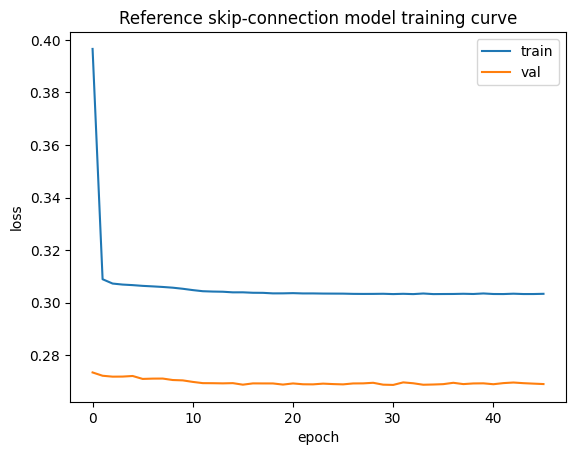

In [12]:
plt.plot(global_history['train_loss'], label='train')
plt.plot(global_history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Reference skip-connection model training curve')
plt.show()

## Evaluation and importance (train and test both)
Same convention as prior notebooks.

In [13]:
def evaluate_per_protein(model: nn.Module, X: np.ndarray, Y: np.ndarray, protein_names: list[str]) -> pd.DataFrame:
    """Per-protein Pearson r and R2 on CPU."""
    model.to('cpu')
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X)).numpy()
    rows = []
    for i, name in enumerate(protein_names):
        r, _ = pearsonr(Y[:, i], preds[:, i])
        r2 = r2_score(Y[:, i], preds[:, i])
        rows.append({'protein': name, 'pearson_r': r, 'r2': r2})
    return pd.DataFrame(rows)


train_m = evaluate_per_protein(global_model, X_rna_corr[train_idx], Y_protein_corr[train_idx], matched_adt_names)
test_m  = evaluate_per_protein(global_model, X_rna_corr[test_idx],  Y_protein_corr[test_idx],  matched_adt_names)
global_metrics = train_m.merge(test_m, on='protein', suffixes=('_train', '_test'))
global_metrics['r_gap'] = global_metrics['pearson_r_train'] - global_metrics['pearson_r_test']

print(f"Median train r: {global_metrics['pearson_r_train'].median():.3f} | "
      f"Median test r: {global_metrics['pearson_r_test'].median():.3f}")

Median train r: 0.396 | Median test r: 0.391


In [14]:
def compute_direct_importance(model: SkipConnectionSparseMLP, gene_names: list[str], protein_names: list[str]) -> pd.DataFrame:
    """|W_direct|, the direct linear path -- directly interpretable, no path-weight product needed."""
    model.to('cpu')
    W = model.direct.weight.detach().numpy()
    return pd.DataFrame(np.abs(W), index=protein_names, columns=gene_names)


def compute_hidden_importance(model: SkipConnectionSparseMLP, gene_names: list[str], protein_names: list[str]) -> pd.DataFrame:
    """|W2 @ W1|, path-weight importance through the mediated (hidden) path only."""
    model.to('cpu')
    W1 = model.fc1.weight.detach().numpy()
    W2 = model.fc2.weight.detach().numpy()
    return pd.DataFrame(np.abs(W2 @ W1), index=protein_names, columns=gene_names)


def cognate_gene_rank(importance_df: pd.DataFrame, gene_map: pd.DataFrame) -> pd.DataFrame:
    """Rank of each protein's cognate RNA gene by importance score (1 = top predictor)."""
    rows = []
    for _, row in gene_map.iterrows():
        gene, adt = row['gene'], row['adt_name']
        if adt not in importance_df.index or gene not in importance_df.columns:
            continue
        ranks = importance_df.loc[adt].rank(ascending=False)
        top_gene = importance_df.loc[adt].idxmax()
        rows.append({
            'protein': adt, 'cognate_gene': gene, 'cognate_rank': int(ranks[gene]),
            'n_genes': len(ranks), 'top_predictor_gene': top_gene,
        })
    return pd.DataFrame(rows).sort_values('cognate_rank').reset_index(drop=True)


direct_importance_df = compute_direct_importance(global_model, gene_union, matched_adt_names)
hidden_importance_df = compute_hidden_importance(global_model, gene_union, matched_adt_names)

direct_cognate_ranks = cognate_gene_rank(direct_importance_df, gene_map)
hidden_cognate_ranks = cognate_gene_rank(hidden_importance_df, gene_map)

print(f"Direct path -- cognate rank-1: {(direct_cognate_ranks['cognate_rank'] == 1).sum()} / {len(direct_cognate_ranks)}")
print(f"Hidden path -- cognate rank-1: {(hidden_cognate_ranks['cognate_rank'] == 1).sum()} / {len(hidden_cognate_ranks)}")

Direct path -- cognate rank-1: 41 / 163
Hidden path -- cognate rank-1: 0 / 163


## Bootstrap stability check -- both paths
For each protein, top-`TOP_K_GENES` genes by importance in each path, scored by recurrence across `N_BOOTSTRAPS` resamples of the training cells (val/test fixed).

In [15]:
def train_on_bootstrap(seed: int) -> SkipConnectionSparseMLP:
    """Train on a bootstrap resample of the training cells (val/test fixed)."""
    rng = np.random.RandomState(seed)
    boot_idx = rng.choice(train_idx, size=len(train_idx), replace=True)
    boot_loader = make_loader(X_rna_corr, Y_protein_corr, boot_idx, BATCH_SIZE, shuffle=True)

    model = SkipConnectionSparseMLP(
        rna_dim=X_rna_corr.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein_corr.shape[1],
    )
    model, _ = fit_model(
        model=model, train_loader=boot_loader, val_loader=val_loader,
        num_epochs=AUX_NUM_EPOCHS, patience=AUX_PATIENCE,
        checkpoint_path=None, train_device=DEVICE, verbose=False,
    )
    return model


bootstrap_top_genes_direct = {protein: [] for protein in matched_adt_names}
bootstrap_top_genes_hidden = {protein: [] for protein in matched_adt_names}

for b in range(N_BOOTSTRAPS):
    print(f'Bootstrap {b + 1}/{N_BOOTSTRAPS}...')
    boot_model = train_on_bootstrap(seed=2000 + b)
    boot_direct = compute_direct_importance(boot_model, gene_union, matched_adt_names)
    boot_hidden = compute_hidden_importance(boot_model, gene_union, matched_adt_names)
    for protein in matched_adt_names:
        bootstrap_top_genes_direct[protein].append(set(boot_direct.loc[protein].nlargest(TOP_K_GENES).index))
        bootstrap_top_genes_hidden[protein].append(set(boot_hidden.loc[protein].nlargest(TOP_K_GENES).index))

print('Bootstrap runs complete.')

Bootstrap 1/5...
Bootstrap 2/5...
Bootstrap 3/5...
Bootstrap 4/5...
Bootstrap 5/5...
Bootstrap runs complete.


In [16]:
def compute_stability_scores(importance_df: pd.DataFrame, bootstrap_top_genes: dict,
                              top_k: int, protein_names: list[str], path_name: str) -> pd.DataFrame:
    """For each protein's top-K genes in the reference model, score bootstrap recurrence frequency."""
    rows = []
    for protein in protein_names:
        full_top_k = importance_df.loc[protein].nlargest(top_k)
        boot_sets = bootstrap_top_genes[protein]
        for gene, score in full_top_k.items():
            freq = sum(gene in s for s in boot_sets) / len(boot_sets)
            rows.append({'protein': protein, 'gene': gene, 'path': path_name, 'importance': score, 'bootstrap_frequency': freq})
    return pd.DataFrame(rows)


stability_direct = compute_stability_scores(direct_importance_df, bootstrap_top_genes_direct, TOP_K_GENES, matched_adt_names, 'direct')
stability_hidden = compute_stability_scores(hidden_importance_df, bootstrap_top_genes_hidden, TOP_K_GENES, matched_adt_names, 'hidden')

print(f"Direct path -- median bootstrap frequency: {stability_direct['bootstrap_frequency'].median():.2f}, "
      f"fraction >=80%: {(stability_direct['bootstrap_frequency'] >= 0.8).mean():.1%}")
print(f"Hidden path -- median bootstrap frequency: {stability_hidden['bootstrap_frequency'].median():.2f}, "
      f"fraction >=80%: {(stability_hidden['bootstrap_frequency'] >= 0.8).mean():.1%}")

Direct path -- median bootstrap frequency: 0.40, fraction >=80%: 33.6%
Hidden path -- median bootstrap frequency: 0.80, fraction >=80%: 63.9%


## Permutation null baseline -- both paths
Shuffle cell order in the protein matrix (real RNA-protein pairing destroyed, protein-protein covariance preserved), retrain `N_NULL_PERMS` times, and use the resulting importance scores as an empirical per-protein, per-path significance threshold.

In [17]:
def train_on_permuted_protein(seed: int) -> SkipConnectionSparseMLP:
    """Train with protein rows shuffled (real RNA-protein pairing destroyed)."""
    rng = np.random.RandomState(seed)
    perm = rng.permutation(n_cells)
    Y_perm = Y_protein_corr[perm]

    perm_train_loader = make_loader(X_rna_corr, Y_perm, train_idx, BATCH_SIZE, shuffle=True)
    perm_val_loader   = make_loader(X_rna_corr, Y_perm, val_idx,   BATCH_SIZE, shuffle=False)

    model = SkipConnectionSparseMLP(
        rna_dim=X_rna_corr.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein_corr.shape[1],
    )
    model, _ = fit_model(
        model=model, train_loader=perm_train_loader, val_loader=perm_val_loader,
        num_epochs=AUX_NUM_EPOCHS, patience=AUX_PATIENCE,
        checkpoint_path=None, train_device=DEVICE, verbose=False,
    )
    return model


null_direct_importances = []
null_hidden_importances = []

for n in range(N_NULL_PERMS):
    print(f'Null permutation {n + 1}/{N_NULL_PERMS}...')
    null_model = train_on_permuted_protein(seed=3000 + n)
    null_direct_importances.append(compute_direct_importance(null_model, gene_union, matched_adt_names))
    null_hidden_importances.append(compute_hidden_importance(null_model, gene_union, matched_adt_names))

print('Null runs complete.')

Null permutation 1/5...
Null permutation 2/5...
Null permutation 3/5...
Null permutation 4/5...
Null permutation 5/5...
Null runs complete.


In [18]:
def null_significance_thresholds(null_importances: list, protein_names: list[str], percentile: float = 95.0) -> pd.Series:
    """Per-protein significance threshold: given percentile of pooled null importance values."""
    thresholds = {}
    for protein in protein_names:
        pooled_null = np.concatenate([null_df.loc[protein].values for null_df in null_importances])
        thresholds[protein] = np.percentile(pooled_null, percentile)
    return pd.Series(thresholds, name='null_threshold')


null_thresholds_direct = null_significance_thresholds(null_direct_importances, matched_adt_names)
null_thresholds_hidden = null_significance_thresholds(null_hidden_importances, matched_adt_names)

validated_direct = stability_direct.merge(null_thresholds_direct.rename('null_threshold'), left_on='protein', right_index=True)
validated_direct['above_null'] = validated_direct['importance'] > validated_direct['null_threshold']
validated_direct['validated'] = validated_direct['above_null'] & (validated_direct['bootstrap_frequency'] >= 0.8)

validated_hidden = stability_hidden.merge(null_thresholds_hidden.rename('null_threshold'), left_on='protein', right_index=True)
validated_hidden['above_null'] = validated_hidden['importance'] > validated_hidden['null_threshold']
validated_hidden['validated'] = validated_hidden['above_null'] & (validated_hidden['bootstrap_frequency'] >= 0.8)

print(f"Direct path -- median null threshold: {null_thresholds_direct.median():.4f} | "
      f"validated pairs: {validated_direct['validated'].sum()} / {len(validated_direct)}")
print(f"Hidden path -- median null threshold: {null_thresholds_hidden.median():.6f} | "
      f"validated pairs: {validated_hidden['validated'].sum()} / {len(validated_hidden)}")
print('\nCheck the null thresholds above against the real importance scale for each path -- '
      'a threshold near zero relative to real scores means the null is barely discriminating '
      '(as seen for the hidden path in nb07), so the bootstrap criterion is doing most of the work.')

Direct path -- median null threshold: 0.0024 | validated pairs: 1095 / 3260
Hidden path -- median null threshold: 0.000000 | validated pairs: 2083 / 3260

Check the null thresholds above against the real importance scale for each path -- a threshold near zero relative to real scores means the null is barely discriminating (as seen for the hidden path in nb07), so the bootstrap criterion is doing most of the work.


## Save results

In [19]:
global_metrics.to_csv(RESULTS_DIR / 'reference_model_metrics.csv', index=False)
direct_cognate_ranks.to_csv(RESULTS_DIR / 'direct_cognate_ranks.csv', index=False)
hidden_cognate_ranks.to_csv(RESULTS_DIR / 'hidden_cognate_ranks.csv', index=False)
direct_importance_df.to_parquet(RESULTS_DIR / 'direct_importance.parquet')
hidden_importance_df.to_parquet(RESULTS_DIR / 'hidden_importance.parquet')
validated_direct.to_csv(RESULTS_DIR / 'validated_direct_path.csv', index=False)
validated_hidden.to_csv(RESULTS_DIR / 'validated_hidden_path.csv', index=False)

print(f'Saved to {RESULTS_DIR}')
print('  reference_model_metrics.csv   -- train/test Pearson r + R2 per protein')
print('  direct_cognate_ranks.csv      -- cognate RNA rank, direct path')
print('  hidden_cognate_ranks.csv      -- cognate RNA rank, hidden path')
print('  validated_direct_path.csv     -- direct path: bootstrap + null validated gene-protein pairs')
print('  validated_hidden_path.csv     -- hidden path: same, for the mediated path')

Saved to /content/drive/MyDrive/covid_citeseq_project/results/sparse_mlp_v3_validation
  reference_model_metrics.csv   -- train/test Pearson r + R2 per protein
  direct_cognate_ranks.csv      -- cognate RNA rank, direct path
  hidden_cognate_ranks.csv      -- cognate RNA rank, hidden path
  validated_direct_path.csv     -- direct path: bootstrap + null validated gene-protein pairs
  validated_hidden_path.csv     -- hidden path: same, for the mediated path
